# 06 - Support Vector Machine

Tries `LinearSVC` on full TF-IDF data and `SVC(kernel='rbf')` on a stratified subsample.
Saves outputs to `reports/06_svm/` and `models/svm_model.pkl`.


In [1]:
import json
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.svm import LinearSVC, SVC

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
REPORT_DIR = ROOT / "reports" / "06_svm"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_style("whitegrid")
LABELS = ["REAL (0)", "FAKE (1)"]
RANDOM_STATE = 42


In [2]:
X_train = joblib.load(DATA_DIR / "X_train_tfidf.pkl")
X_val = joblib.load(DATA_DIR / "X_val_tfidf.pkl")
y_train = np.array(joblib.load(DATA_DIR / "y_train.pkl"))
y_val = np.array(joblib.load(DATA_DIR / "y_val.pkl"))

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")
print("Train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val labels  :", dict(zip(*np.unique(y_val, return_counts=True))))


X_train: (27055, 10000) | X_val: (5798, 10000)
Train labels: {np.int64(0): np.int64(14836), np.int64(1): np.int64(12219)}
Val labels  : {np.int64(0): np.int64(3179), np.int64(1): np.int64(2619)}


In [3]:
baseline = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
t0 = time.time()
baseline.fit(X_train, y_train)
baseline_time = time.time() - t0
baseline_pred = baseline.predict(X_val)

print(f"Baseline time: {baseline_time:.2f}s")
print(f"Baseline accuracy: {accuracy_score(y_val, baseline_pred):.4f}")
print(f"Baseline weighted F1: {f1_score(y_val, baseline_pred, average='weighted'):.4f}")


Baseline time: 0.56s
Baseline accuracy: 0.9886
Baseline weighted F1: 0.9886


In [4]:
param_grid_linear = {"C": [0.01, 0.1, 1, 10]}

gs_linear = GridSearchCV(
    LinearSVC(max_iter=3000, random_state=RANDOM_STATE),
    param_grid=param_grid_linear,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1,
)

t0 = time.time()
gs_linear.fit(X_train, y_train)
training_time = time.time() - t0

print(f"LinearSVC GridSearch time: {training_time:.2f}s")
print("Best params:", gs_linear.best_params_)
print(f"Best CV weighted F1: {gs_linear.best_score_:.4f}")


Fitting 5 folds for each of 4 candidates, totalling 20 fits


LinearSVC GridSearch time: 4.91s
Best params: {'C': 1}
Best CV weighted F1: 0.9871


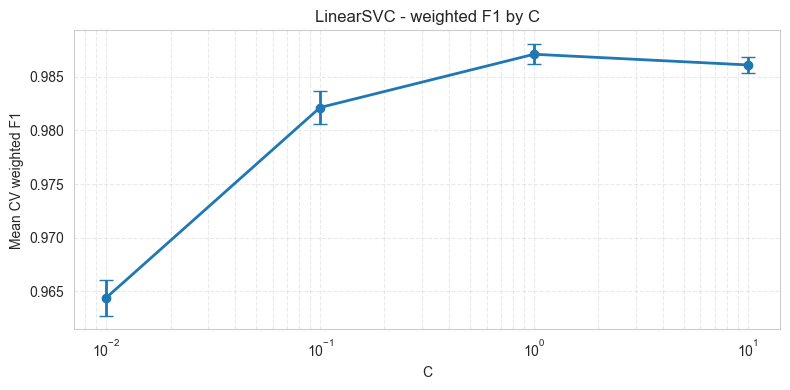

In [5]:
linear_cv = pd.DataFrame(gs_linear.cv_results_)
linear_cv.to_csv(REPORT_DIR / "linearsvc_gridsearch_results.csv", index=False)

plt.figure(figsize=(8, 4))
plt.errorbar(
    linear_cv["param_C"].astype(float),
    linear_cv["mean_test_score"],
    yerr=linear_cv["std_test_score"],
    marker="o",
    capsize=5,
    linewidth=2,
)
plt.xscale("log")
plt.title("LinearSVC - weighted F1 by C")
plt.xlabel("C")
plt.ylabel("Mean CV weighted F1")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(REPORT_DIR / "linearsvc_c_tuning.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "svm_linearsvc_c_tuning.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
N_SUB = min(400, X_train.shape[0], X_val.shape[0])
splitter_train = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
splitter_val = StratifiedShuffleSplit(n_splits=1, train_size=N_SUB, random_state=RANDOM_STATE)
idx_train, _ = next(splitter_train.split(X_train, y_train))
idx_val, _ = next(splitter_val.split(X_val, y_val))

X_sub = X_train[idx_train].toarray()
y_sub = y_train[idx_train]
X_val_sub = X_val[idx_val].toarray()
y_val_sub = y_val[idx_val]

rbf_rows = []
for C in [0.1, 1, 10]:
    for gamma in ["scale", "auto"]:
        t0 = time.time()
        model = SVC(kernel="rbf", C=C, gamma=gamma, random_state=RANDOM_STATE)
        model.fit(X_sub, y_sub)
        pred = model.predict(X_val_sub)
        rbf_rows.append({
            "C": C,
            "gamma": gamma,
            "val_f1_weighted": f1_score(y_val_sub, pred, average="weighted", zero_division=0),
            "val_accuracy": accuracy_score(y_val_sub, pred),
            "time_seconds": time.time() - t0,
        })

rbf_results = pd.DataFrame(rbf_rows).sort_values("val_f1_weighted", ascending=False)
rbf_results.to_csv(REPORT_DIR / "rbf_subsample_results.csv", index=False)
display(rbf_results)


,C,gamma,val_f1_weighted,val_accuracy,time_seconds
4,10.0,scale,0.939722,0.9400,1.115198
2,1.0,scale,0.932034,0.9325,1.269865
0,0.1,scale,0.387407,0.5475,1.352827
1,0.1,auto,0.387407,0.5475,1.076893
3,1.0,auto,0.387407,0.5475,1.013827
5,10.0,auto,0.387407,0.5475,1.017491


In [7]:
best_model = gs_linear.best_estimator_
y_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1_weighted = f1_score(y_val, y_pred, average="weighted")
report_dict = classification_report(y_val, y_pred, target_names=LABELS, output_dict=True)
report_text = classification_report(y_val, y_pred, target_names=LABELS)
cm = confusion_matrix(y_val, y_pred)

print(report_text)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation weighted F1: {val_f1_weighted:.4f}")


              precision    recall  f1-score   support

    REAL (0)       0.99      0.99      0.99      3179
    FAKE (1)       0.99      0.98      0.99      2619

    accuracy                           0.99      5798
   macro avg       0.99      0.99      0.99      5798
weighted avg       0.99      0.99      0.99      5798

Validation accuracy: 0.9886
Validation weighted F1: 0.9886


In [8]:
pd.DataFrame(report_dict).transpose().to_csv(REPORT_DIR / "classification_report.csv")

metrics = {
    "selected_model": "LinearSVC",
    "best_params": gs_linear.best_params_,
    "best_cv_f1_weighted": float(gs_linear.best_score_),
    "baseline_time_seconds": float(baseline_time),
    "training_time_seconds": float(training_time),
    "validation_accuracy": float(val_accuracy),
    "validation_f1_weighted": float(val_f1_weighted),
    "confusion_matrix": cm.tolist(),
    "rbf_best_subsample": rbf_results.iloc[0].to_dict(),
}
with open(REPORT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(REPORT_DIR / "training_log.txt", "w", encoding="utf-8") as f:
    f.write(f"LinearSVC GridSearch time: {training_time:.2f}s\n")
    f.write(f"Best params: {gs_linear.best_params_}\n")
    f.write(f"Best CV weighted F1: {gs_linear.best_score_:.6f}\n")
    f.write(f"Validation accuracy: {val_accuracy:.6f}\n")
    f.write(f"Validation weighted F1: {val_f1_weighted:.6f}\n\n")
    f.write(report_text)

model_path = MODELS_DIR / "svm_model.pkl"
joblib.dump(best_model, model_path)
print("Saved model:", model_path)


Saved model: /Users/duyhung/Desktop/CHUNG/HUST/Fake-News-Detection/models/svm_model.pkl


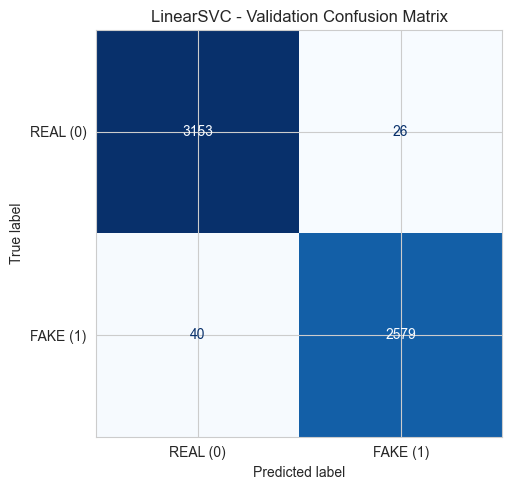

/var/folders/bt/x0xylfv90fz2hms4m1hdtcy80000gn/T/ipykernel_55949/2392060292.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="model", y="weighted_f1", ax=ax, palette=["steelblue", "tomato"])


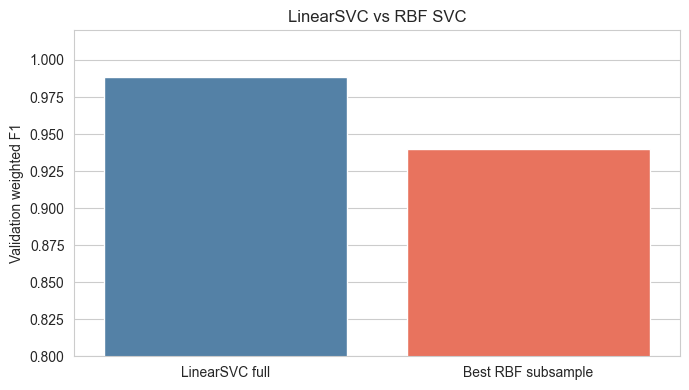

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
    cmap="Blues", ax=ax, values_format="d", colorbar=False
)
ax.set_title("LinearSVC - Validation Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "svm_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
comparison = pd.DataFrame({
    "model": ["LinearSVC full", "Best RBF subsample"],
    "weighted_f1": [val_f1_weighted, float(rbf_results.iloc[0]["val_f1_weighted"])],
})
sns.barplot(data=comparison, x="model", y="weighted_f1", ax=ax, palette=["steelblue", "tomato"])
ax.set_ylim(0.80, 1.02)
ax.set_title("LinearSVC vs RBF SVC")
ax.set_ylabel("Validation weighted F1")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(REPORT_DIR / "kernel_comparison.png", dpi=150, bbox_inches="tight")
plt.savefig(ROOT / "reports" / "svm_kernel_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
